<a href="https://colab.research.google.com/github/Dishti26/employee-predicition-/blob/main/Copy_of_employee_attrition_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Prediction System



In [40]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn

In [41]:
from google.colab import files

uploaded = files.upload()
data_path = next(iter(uploaded))
print(f"Uploaded file: {data_path}")

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv
Uploaded file: WA_Fn-UseC_-HR-Employee-Attrition (1).csv


In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

In [43]:
df = pd.read_csv(data_path)
print(f"Raw shape: {df.shape}")
display(df.head())

missing_report = (
    df.isna().sum().rename("missing_count").reset_index().rename(columns={"index": "feature"})
)
missing_report["missing_pct"] = (missing_report["missing_count"] / len(df) * 100).round(2)
display(missing_report[missing_report["missing_count"] > 0])

identifier_columns = [column for column in ["EmployeeNumber"] if column in df.columns]
constant_columns = [column for column in df.columns if df[column].nunique(dropna=False) <= 1]
df = df.drop(columns=sorted(set(identifier_columns + constant_columns)), errors="ignore")
df = df.drop_duplicates().reset_index(drop=True)
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

print(f"Cleaned shape: {df.shape}")
print(f"Attrition rate: {df['Attrition'].mean() * 100:.2f}%")

Raw shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


,feature,missing_count,missing_pct


Cleaned shape: (1470, 31)
Attrition rate: 16.12%


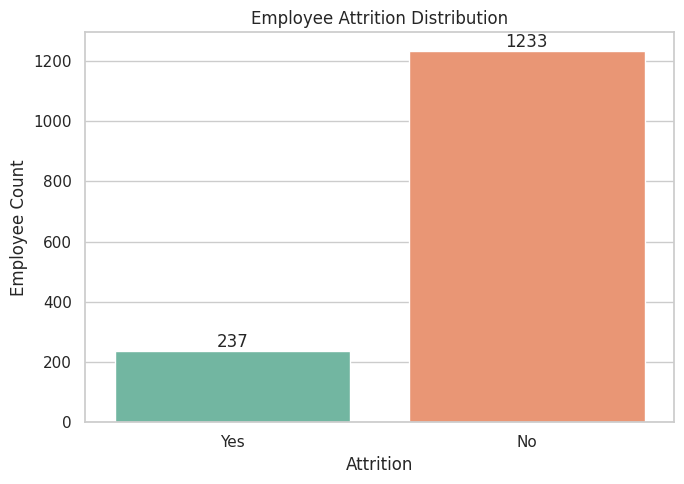

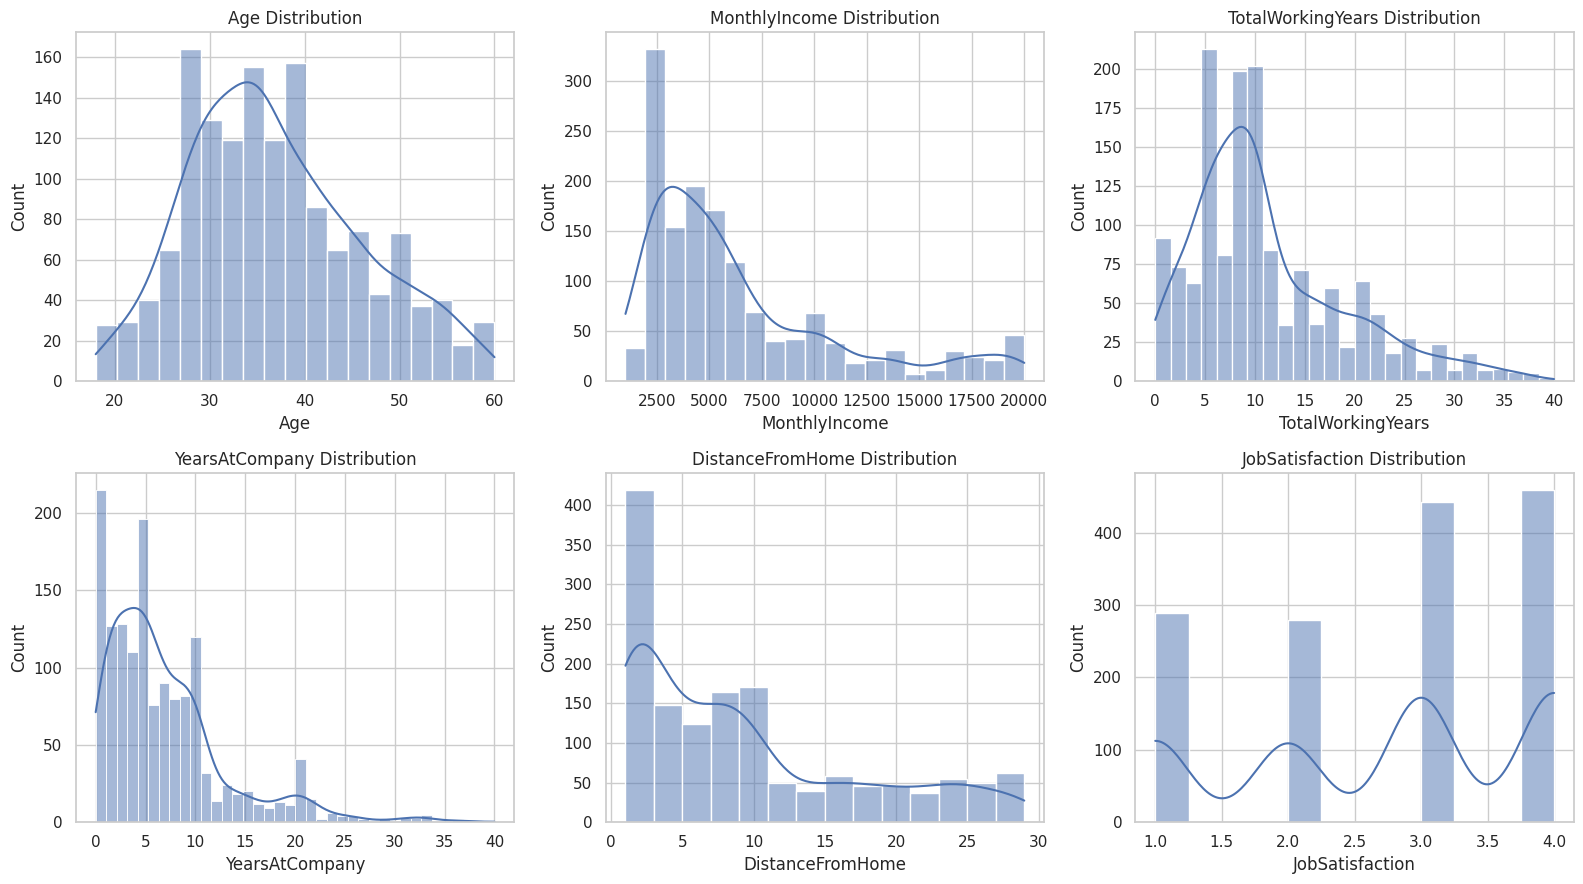

In [44]:
plt.figure(figsize=(7, 5))
labels = df["Attrition"].map({0: "No", 1: "Yes"})
ax = sns.countplot(x=labels, hue=labels, palette="Set2", legend=False)
ax.set_title("Employee Attrition Distribution")
ax.set_xlabel("Attrition")
ax.set_ylabel("Employee Count")
for patch in ax.patches:
    height = int(patch.get_height())
    ax.annotate(f"{height}", (patch.get_x() + patch.get_width() / 2.0, height), ha="center", va="bottom")
plt.tight_layout()
plt.show()

candidate_columns = [
    column for column in ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "DistanceFromHome", "JobSatisfaction"]
    if column in df.columns
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for index, column in enumerate(candidate_columns):
    sns.histplot(df[column], kde=True, ax=axes[index], color="#4C72B0")
    axes[index].set_title(f"{column} Distribution")
for index in range(len(candidate_columns), len(axes)):
    axes[index].axis("off")
fig.tight_layout()
plt.show()

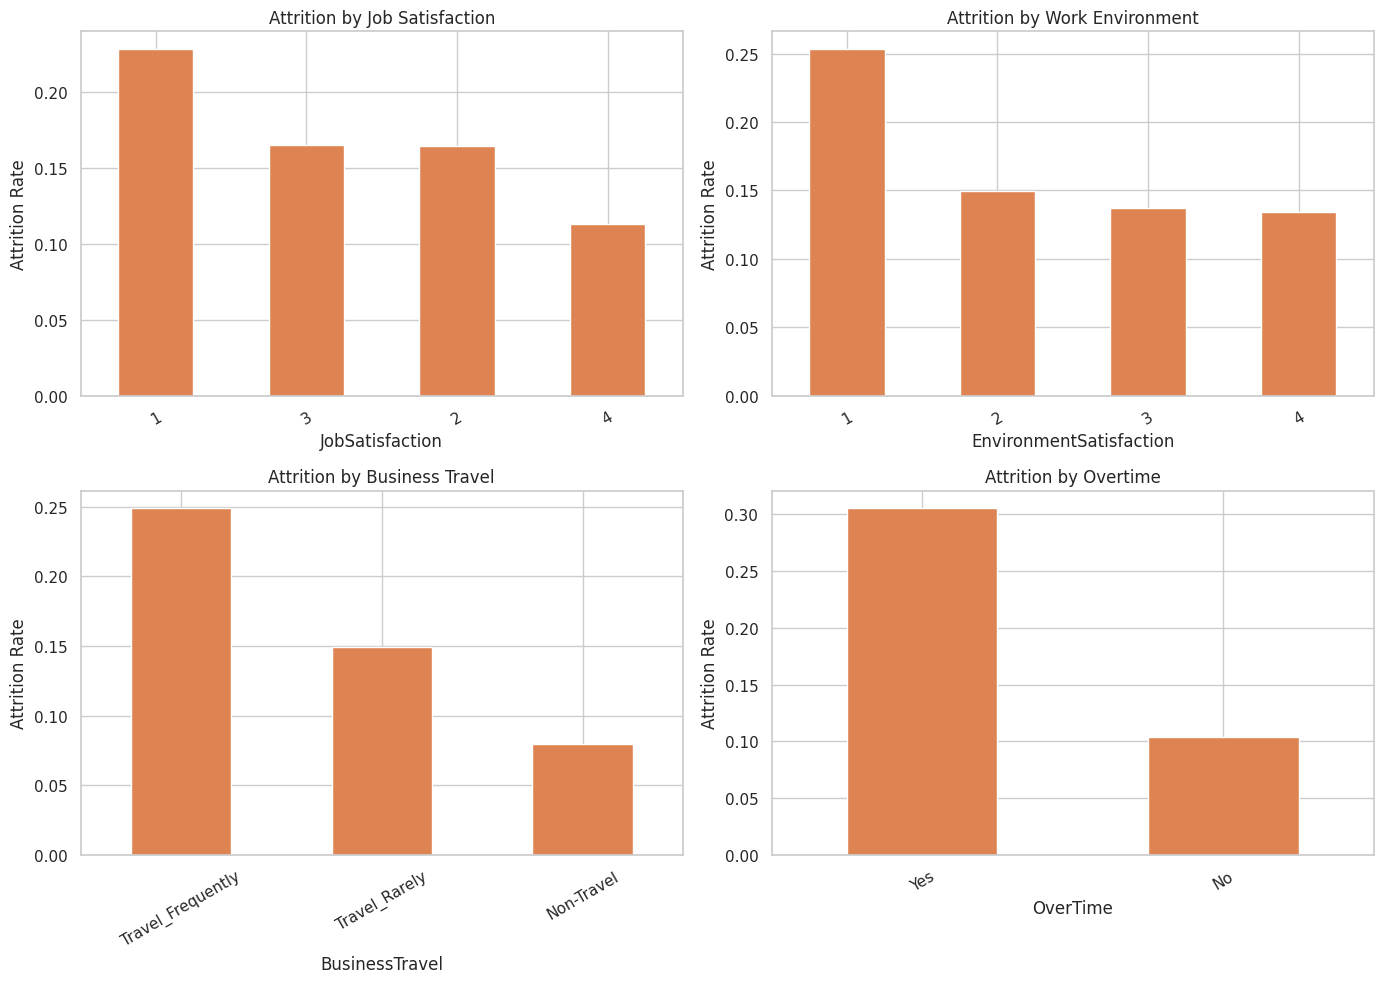

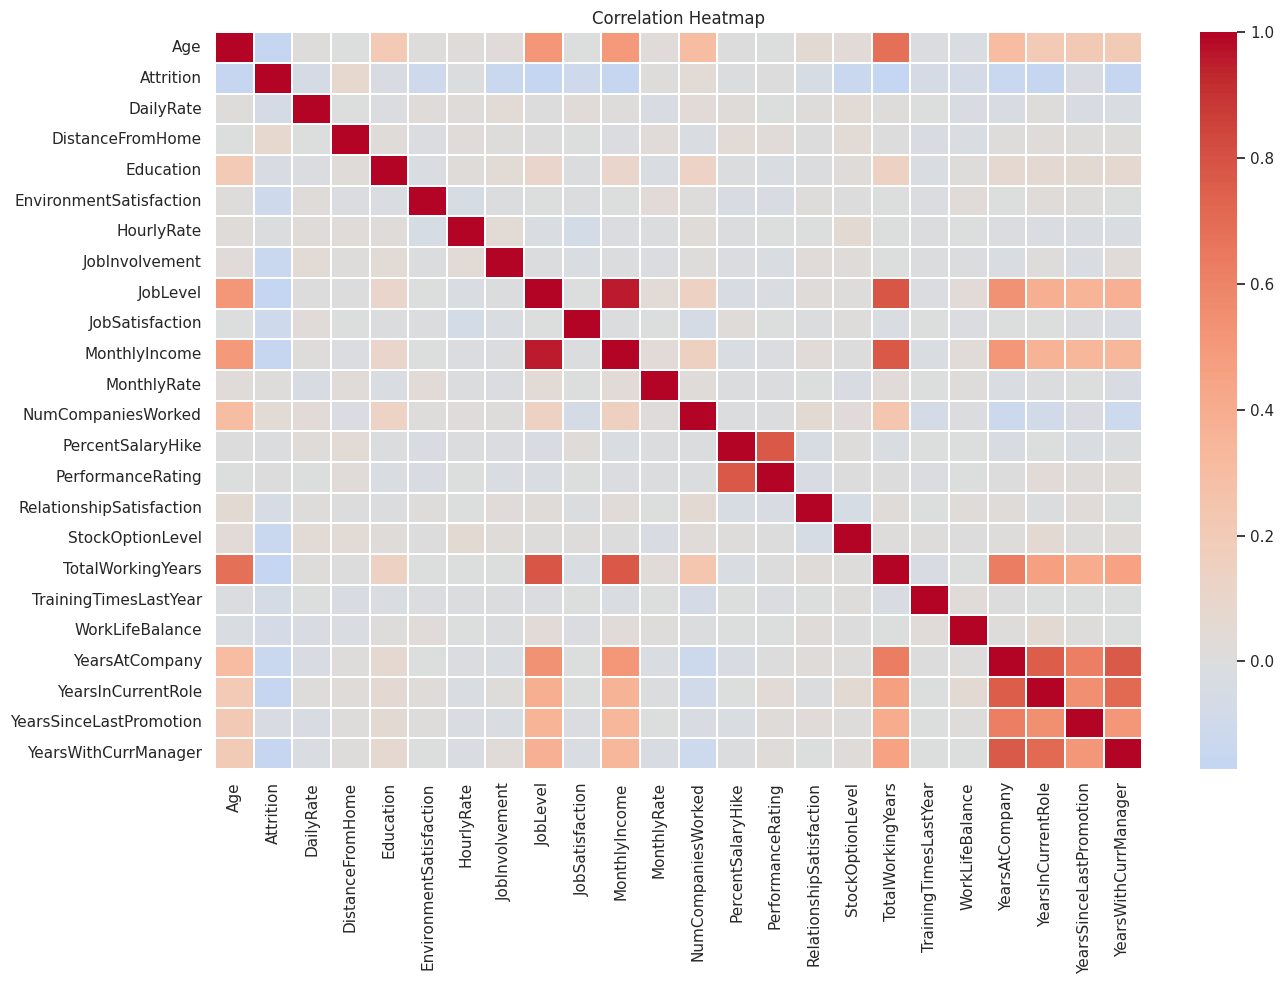

In [45]:
relationship_specs = [
    ("JobSatisfaction", "Attrition by Job Satisfaction"),
    ("EnvironmentSatisfaction", "Attrition by Work Environment"),
    ("BusinessTravel", "Attrition by Business Travel"),
    ("OverTime", "Attrition by Overtime")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (feature, title) in zip(axes, relationship_specs):
    if feature in df.columns:
        normalized = (
            pd.crosstab(df[feature], df["Attrition"], normalize="index")
            .reindex(columns=[0, 1], fill_value=0)
            .rename(columns={0: "No", 1: "Yes"})
        )
        normalized["Yes"].sort_values(ascending=False).plot(kind="bar", color="#DD8452", ax=ax)
        ax.set_title(title)
        ax.set_ylabel("Attrition Rate")
        ax.tick_params(axis="x", rotation=30)
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(numeric_only=True), cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing and model training

In [46]:
# Feature Engineering

df["PromotionDelay"] = df["YearsAtCompany"] - df["YearsSinceLastPromotion"]

df["OverTime"] = df["OverTime"].map({"Yes":1,"No":0})

df["WorkloadScore"] = df["JobInvolvement"] * df["OverTime"]

df["IncomeExperienceRatio"] = df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)

df["WorkStability"] = df["YearsAtCompany"] / (df["TotalWorkingYears"] + 1)

df["SatisfactionScore"] = (
    df["JobSatisfaction"] +
    df["EnvironmentSatisfaction"] +
    df["RelationshipSatisfaction"]
)

In [58]:
X = df.drop(columns="Attrition")
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

def build_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight={0: 1, 1: 10}, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, class_weight={0: 1, 1: 10}, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=4, class_weight={0: 1, 1: 10}, random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
fitted_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", build_preprocessor()), ("model", model)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
    })
    fitted_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(output_dir / "model_comparison_metrics.csv", index=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.836735,0.488889,0.468085,0.478261
1,Logistic Regression,0.700680,0.324786,0.808511,0.463415
2,Decision Tree,0.625850,0.221239,0.531915,0.312500


In [48]:
pipeline_rf = Pipeline(steps=[("preprocessor", build_preprocessor()), ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
pipeline_rf.fit(X_train, y_train)
rf_pred = pipeline_rf.predict(X_test)

In [49]:
import joblib

joblib.dump(pipeline_rf, "attrition_model.pkl")

['attrition_model.pkl']

In [50]:
from google.colab import files

files.download("attrition_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

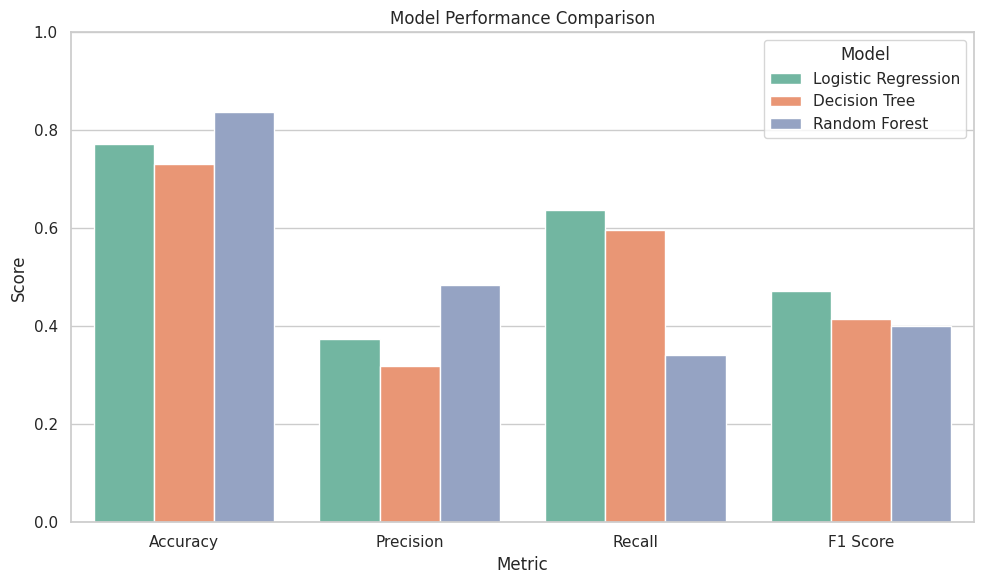


Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.80      0.85       247
           1       0.38      0.64      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.83      0.77      0.79       294



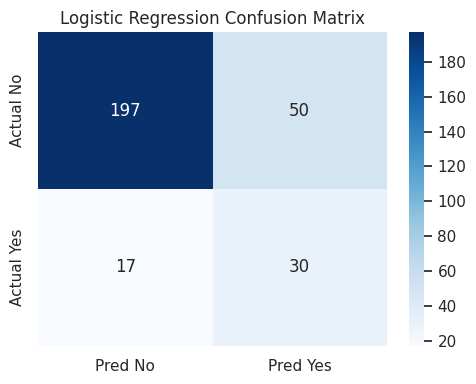


Decision Tree
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       247
           1       0.32      0.60      0.41        47

    accuracy                           0.73       294
   macro avg       0.61      0.68      0.62       294
weighted avg       0.81      0.73      0.76       294



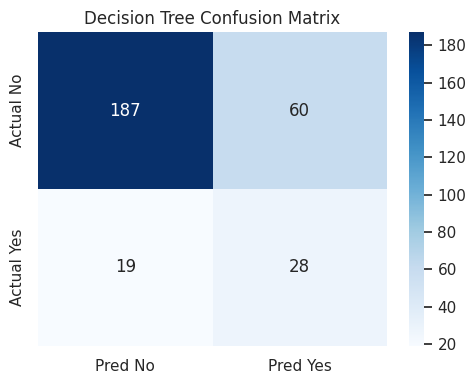


Random Forest
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       247
           1       0.48      0.34      0.40        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.65       294
weighted avg       0.82      0.84      0.82       294



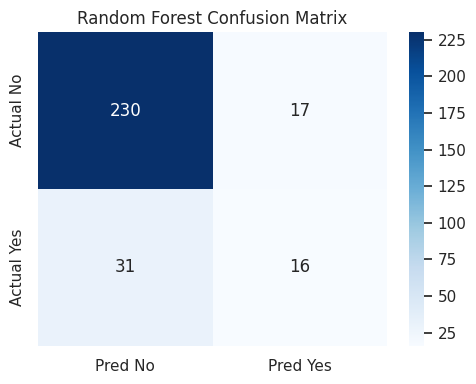

In [51]:
plt.figure(figsize=(10, 6))
plot_df = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1 Score"], var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Set2")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

for model_name, pipeline in fitted_models.items():
    predictions = pipeline.predict(X_test)
    print(f"\n{model_name}")
    print(classification_report(y_test, predictions, zero_division=0))
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred No", "Pred Yes"], yticklabels=["Actual No", "Actual Yes"])
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

## Top factors influencing attrition

,feature,importance
48,cat__JobRole_Research Director,1.733065
51,cat__JobRole_Sales Representative,1.238990
45,cat__JobRole_Laboratory Technician,1.195024
29,cat__BusinessTravel_Non-Travel,1.060134
12,num__OverTime,0.933435
35,cat__EducationField_Human Resources,0.924646
39,cat__EducationField_Other,0.853025
30,cat__BusinessTravel_Travel_Frequently,0.851507
43,cat__JobRole_Healthcare Representative,0.719015
44,cat__JobRole_Human Resources,0.696883


,feature,importance
9,num__MonthlyIncome,0.069637
0,num__Age,0.054810
17,num__TotalWorkingYears,0.047601
20,num__YearsAtCompany,0.040440
26,num__IncomeExperienceRatio,0.040413
1,num__DailyRate,0.039289
12,num__OverTime,0.039152
24,num__PromotionDelay,0.037358
25,num__WorkloadScore,0.036124
27,num__WorkStability,0.035486


,feature,importance_mean,importance_std
12,num__OverTime,0.021542,0.006765
25,num__WorkloadScore,0.016553,0.005808
2,num__DistanceFromHome,0.012472,0.005220
54,cat__MaritalStatus_Single,0.008390,0.005395
1,num__DailyRate,0.008163,0.004778
16,num__StockOptionLevel,0.008163,0.006665
10,num__MonthlyRate,0.005896,0.002625
8,num__JobSatisfaction,0.005669,0.002683
49,cat__JobRole_Research Scientist,0.005215,0.003901
53,cat__MaritalStatus_Married,0.005215,0.003484


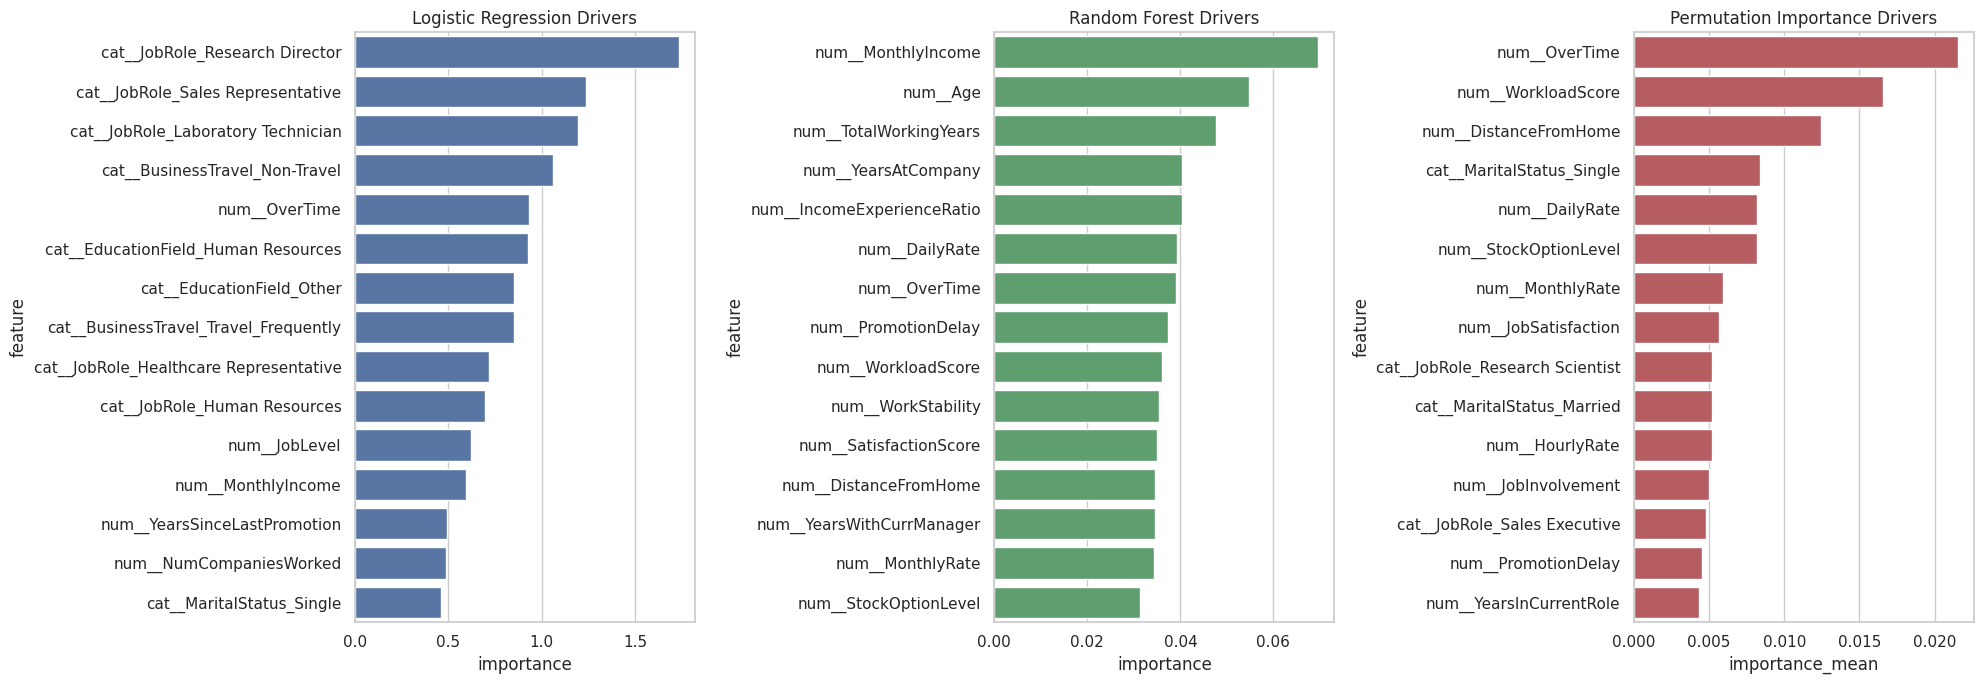

In [52]:
lr_pipeline = fitted_models["Logistic Regression"]
rf_pipeline = fitted_models["Random Forest"]

lr_feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
lr_coefficients = np.abs(lr_pipeline.named_steps["model"].coef_[0])
lr_importance = pd.DataFrame({"feature": lr_feature_names, "importance": lr_coefficients}).sort_values(by="importance", ascending=False).head(15)
display(lr_importance)

rf_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_pipeline.named_steps["model"].feature_importances_
rf_importance = pd.DataFrame({"feature": rf_feature_names, "importance": rf_importances}).sort_values(by="importance", ascending=False).head(15)
display(rf_importance)

transformed_X_test = rf_pipeline.named_steps["preprocessor"].transform(X_test)
permutation = permutation_importance(rf_pipeline.named_steps["model"], transformed_X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1)
permutation_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values(by="importance_mean", ascending=False).head(15)
display(permutation_df)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.barplot(data=lr_importance, x="importance", y="feature", color="#4C72B0", ax=axes[0])
axes[0].set_title("Logistic Regression Drivers")
sns.barplot(data=rf_importance, x="importance", y="feature", color="#55A868", ax=axes[1])
axes[1].set_title("Random Forest Drivers")
sns.barplot(data=permutation_df, x="importance_mean", y="feature", color="#C44E52", ax=axes[2])
axes[2].set_title("Permutation Importance Drivers")
plt.tight_layout()
plt.show()

In [53]:
print("Most important attrition factors usually come from job satisfaction, overtime, income, tenure, travel, and work environment variables.")
print("Use the importance tables above as your final ranked factors for this run.")

Most important attrition factors usually come from job satisfaction, overtime, income, tenure, travel, and work environment variables.
Use the importance tables above as your final ranked factors for this run.


In [54]:
sample_employee_data = [[35,5000,5,3,1]] # This is the original input, kept for reference

# The model was trained on a DataFrame with many features.
# We need to create a sample_employee DataFrame with the correct column structure.
# Using X_test.iloc[0] as a template and updating some values for demonstration.
sample_employee_df = X_test.iloc[[0]].copy()
sample_employee_df['Age'] = sample_employee_data[0][0]
sample_employee_df['MonthlyIncome'] = sample_employee_data[0][1]
sample_employee_df['TotalWorkingYears'] = sample_employee_data[0][2]
sample_employee_df['YearsAtCompany'] = sample_employee_data[0][3]
sample_employee_df['JobSatisfaction'] = sample_employee_data[0][4]

# Use the fitted pipeline to make the prediction
prediction = pipeline_rf.predict(sample_employee_df)

if prediction[0] == 1:
    print("Employee likely to leave")
else:
    print("Employee likely to stay")

Employee likely to stay


### Prediction for an employee likely to STAY

In [55]:
# Define the employee's characteristics for a 'likely to stay' scenario
employee_input_data_stay = {
    'Age': 40,
    'BusinessTravel': 'Non-Travel',
    'DailyRate': 1200,
    'Department': 'Research & Development',
    'DistanceFromHome': 2,
    'Education': 4,
    'EducationField': 'Medical',
    'EnvironmentSatisfaction': 4,
    'Gender': 'Male',
    'HourlyRate': 70,
    'JobInvolvement': 4,
    'JobLevel': 3,
    'JobRole': 'Research Director',
    'JobSatisfaction': 4,
    'MaritalStatus': 'Married',
    'MonthlyIncome': 10000,
    'MonthlyRate': 20000,
    'NumCompaniesWorked': 1,
    'OverTime': 'No',
    'PercentSalaryHike': 20,
    'PerformanceRating': 4,
    'RelationshipSatisfaction': 4,
    'StockOptionLevel': 3,
    'TotalWorkingYears': 15,
    'TrainingTimesLastYear': 3,
    'WorkLifeBalance': 4,
    'YearsAtCompany': 10,
    'YearsInCurrentRole': 7,
    'YearsSinceLastPromotion': 3,
    'YearsWithCurrManager': 7
}

# Create a DataFrame from the input data, matching the structure of X_test
sample_employee_df_stay = X_test.iloc[[0]].copy()

# Update the values for the specified features
for feature, value in employee_input_data_stay.items():
    if feature in sample_employee_df_stay.columns:
        sample_employee_df_stay[feature] = value

# Generate new engineered features for the sample employee
sample_employee_df_stay["PromotionDelay"] = sample_employee_df_stay["YearsAtCompany"] - sample_employee_df_stay["YearsSinceLastPromotion"]
sample_employee_df_stay["OverTime"] = sample_employee_df_stay["OverTime"].map({"Yes":1,"No":0})
sample_employee_df_stay["WorkloadScore"] = sample_employee_df_stay["JobInvolvement"] * sample_employee_df_stay["OverTime"]
sample_employee_df_stay["IncomeExperienceRatio"] = sample_employee_df_stay["MonthlyIncome"] / (sample_employee_df_stay["TotalWorkingYears"] + 1)
sample_employee_df_stay["WorkStability"] = sample_employee_df_stay["YearsAtCompany"] / (sample_employee_df_stay["TotalWorkingYears"] + 1)
sample_employee_df_stay["SatisfactionScore"] = (
    sample_employee_df_stay["JobSatisfaction"] +
    sample_employee_df_stay["EnvironmentSatisfaction"] +
    sample_employee_df_stay["RelationshipSatisfaction"]
)

# Make the prediction using the fitted pipeline
prediction_stay = pipeline_rf.predict(sample_employee_df_stay)

# Print the prediction result
if prediction_stay[0] == 1:
    print("Prediction: Employee is likely to leave.")
else:
    print("Prediction: Employee is likely to stay.")

Prediction: Employee is likely to stay.


### Prediction for an employee likely to LEAVE

In [56]:
# Define the employee's characteristics for a 'likely to leave' scenario
employee_input_data_leave = {
    'Age': 25, # Younger age, potentially less rooted
    'BusinessTravel': 'Travel_Frequently', # Frequent travel often linked to attrition
    'DailyRate': 600,
    'Department': 'Sales',
    'DistanceFromHome': 20, # Longer commute
    'Education': 2,
    'EnvironmentSatisfaction': 1, # Very low environment satisfaction
    'Gender': 'Female',
    'JobInvolvement': 2,
    'JobLevel': 1, # Entry-level, potentially less career progression
    'JobRole': 'Sales Representative', # Often higher attrition rates
    'JobSatisfaction': 1, # Very low job satisfaction
    'MaritalStatus': 'Single',
    'MonthlyIncome': 2500, # Lower income
    'OverTime': 'Yes', # A strong predictor of attrition
    'PercentSalaryHike': 10,
    'PerformanceRating': 2,
    'RelationshipSatisfaction': 2, # Low relationship satisfaction
    'StockOptionLevel': 0,
    'TotalWorkingYears': 3, # Less overall experience
    'TrainingTimesLastYear': 1,
    'WorkLifeBalance': 2,
    'YearsAtCompany': 1, # Short tenure at company
    'YearsInCurrentRole': 1,
    'YearsSinceLastPromotion': 2, # Recent promotion, but still long time since last one
    'YearsWithCurrManager': 1
}

# Create a DataFrame from the input data, matching the structure of X_test
sample_employee_df_leave = X_test.iloc[[0]].copy()

# Update the values for the specified features
for feature, value in employee_input_data_leave.items():
    if feature in sample_employee_df_leave.columns:
        sample_employee_df_leave[feature] = value

# Generate new engineered features for the sample employee
sample_employee_df_leave["PromotionDelay"] = sample_employee_df_leave["YearsAtCompany"] - sample_employee_df_leave["YearsSinceLastPromotion"]
sample_employee_df_leave["OverTime"] = sample_employee_df_leave["OverTime"].map({"Yes":1,"No":0})
sample_employee_df_leave["WorkloadScore"] = sample_employee_df_leave["JobInvolvement"] * sample_employee_df_leave["OverTime"]
sample_employee_df_leave["IncomeExperienceRatio"] = sample_employee_df_leave["MonthlyIncome"] / (sample_employee_df_leave["TotalWorkingYears"] + 1)
sample_employee_df_leave["WorkStability"] = sample_employee_df_leave["YearsAtCompany"] / (sample_employee_df_leave["TotalWorkingYears"] + 1)
sample_employee_df_leave["SatisfactionScore"] = (
    sample_employee_df_leave["JobSatisfaction"] +
    sample_employee_df_leave["EnvironmentSatisfaction"] +
    sample_employee_df_leave["RelationshipSatisfaction"]
)

# Make the prediction using the fitted pipeline
prediction_leave = pipeline_rf.predict(sample_employee_df_leave)

# Print the prediction result
if prediction_leave[0] == 1:
    print("Prediction: Employee is likely to leave.")
else:
    print("Prediction: Employee is likely to stay.")

Prediction: Employee is likely to leave.


### Interactive Employee Attrition Prediction

Use the sliders and dropdowns below to set the characteristics of a hypothetical employee. Click the 'Run Interact' button to get a real-time prediction from the model on whether the employee is likely to stay or leave. For features not controlled by widgets, default values from `X_test` will be used.

In [65]:
import ipywidgets as widgets
from ipywidgets import interact_manual, Output # Import Output widget
from IPython.display import display, clear_output
import pandas as pd

# Create a dedicated output widget for the prediction message
output_area = Output()

def predict_attrition_interactive(**kwargs):
    """
    Prepares employee data from widget inputs, runs the prediction pipeline,
    and displays the attrition prediction.
    """
    sample_employee_df = X_test.iloc[[0]].copy()

    for feature, value in kwargs.items():
        if feature in sample_employee_df.columns:
            sample_employee_df[feature] = value

    sample_employee_df["PromotionDelay"] = sample_employee_df["YearsAtCompany"] - sample_employee_df["YearsSinceLastPromotion"]
    sample_employee_df["OverTime"] = sample_employee_df["OverTime"].map({"Yes":1,"No":0})
    sample_employee_df["WorkloadScore"] = sample_employee_df["JobInvolvement"] * sample_employee_df["OverTime"]
    sample_employee_df["IncomeExperienceRatio"] = sample_employee_df["MonthlyIncome"] / (sample_employee_df["TotalWorkingYears"] + 1)
    sample_employee_df["WorkStability"] = sample_employee_df["YearsAtCompany"] / (sample_employee_df["TotalWorkingYears"] + 1)
    sample_employee_df["SatisfactionScore"] = (
        sample_employee_df["JobSatisfaction"] +
        sample_employee_df["EnvironmentSatisfaction"] +
        sample_employee_df["RelationshipSatisfaction"]
    )

    prediction = pipeline_rf.predict(sample_employee_df)

    # Display output within the dedicated output_area
    with output_area:
        clear_output(wait=True) # Clear previous output within this area
        # --- Debugging prints added here ---
        print("--- Input DataFrame for Prediction ---")
        display(sample_employee_df[list(kwargs.keys())]) # Display only the changed features
        print(f"Raw Model Prediction: {prediction[0]}")
        print("--------------------------------------")
        # --- End Debugging prints ---

        if prediction[0] == 1:
            print("Prediction: Employee is likely to leave.")
        else:
            print("Prediction: Employee is likely to stay.")
    return # No return value, output handled by output_area

age_widget = widgets.IntSlider(min=18, max=60, step=1, value=30, description='Age')
monthly_income_widget = widgets.IntSlider(min=1000, max=20000, step=100, value=4500, description='Monthly Income')
total_working_years_widget = widgets.IntSlider(min=0, max=40, step=1, value=10, description='Total Working Years')
years_at_company_widget = widgets.IntSlider(min=0, max=40, step=1, value=5, description='Years At Company')
job_satisfaction_widget = widgets.IntSlider(min=1, max=4, step=1, value=3, description='Job Satisfaction')
environment_satisfaction_widget = widgets.IntSlider(min=1, max=4, step=1, value=3, description='Environment Satisfaction')
overtime_widget = widgets.Dropdown(options=['No', 'Yes'], value='No', description='OverTime')
business_travel_widget = widgets.Dropdown(options=['Non-Travel', 'Travel_Rarely', 'Travel_Frequently'], value='Travel_Rarely', description='Business Travel')
marital_status_widget = widgets.Dropdown(options=['Single', 'Married', 'Divorced'], value='Married', description='Marital Status')

# Assign to _ to suppress implicit display of the Interactive object itself
_controls = interact_manual(
    predict_attrition_interactive,
    Age=age_widget,
    MonthlyIncome=monthly_income_widget,
    TotalWorkingYears=total_working_years_widget,
    YearsAtCompany=years_at_company_widget,
    JobSatisfaction=job_satisfaction_widget,
    EnvironmentSatisfaction=environment_satisfaction_widget,
    OverTime=overtime_widget,
    BusinessTravel=business_travel_widget,
    MaritalStatus=marital_status_widget
)

# Display the controls and the output area in a single VBox
display(widgets.VBox([_controls.widget, output_area]))

interactive(children=(IntSlider(value=30, description='Age', max=60, min=18), IntSlider(value=4500, descriptio…